# 📊 Processamento Completo de KPIs - 30 Indicadores
## Fatores Socioeconômicos da Criminalidade no Brasil

**Objetivo:** Calcular e visualizar todos os KPIs implementados do projeto:
- População (2 KPIs)
- IDHM (4 KPIs)
- Educação (5 KPIs)
- Segurança - Contagens (8 KPIs)
- Segurança - Taxas (7 KPIs)
- Features Temporais (3 KPIs)
- Índice de Risco (1 KPI)

**Total: 30 KPIs**

In [1]:
# 1. IMPORTAÇÕES E CONFIGURAÇÕES
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.preprocessing import MinMaxScaler

warnings.filterwarnings('ignore')

# Configuração de visualização
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 10

# Diretórios
base_path = Path('../datasets')
output_path = Path('../dados_saida')
output_path.mkdir(exist_ok=True)

print('Bibliotecas carregadas com sucesso.')

Bibliotecas carregadas com sucesso.


In [2]:
# 2. CARREGAMENTO DOS DADOS BRUTOS
print('=' * 80)
print('2. CARREGAMENTO DOS DADOS BRUTOS')
print('=' * 80)

# Carregar dados de população
df_populacao = pd.read_csv(base_path / 'populacao' / '2016-2021.csv')
print(f'População: {df_populacao.shape[0]} linhas e {df_populacao.shape[1]} colunas')

# Carregar dados de crimes
df_crimes = pd.read_csv(base_path / 'crimes' / '2016-2021.csv')
print(f'Crimes: {df_crimes.shape[0]} linhas e {df_crimes.shape[1]} colunas')

# Carregar dados de educação
df_educacao = pd.read_csv(base_path / 'educacao' / '2017-2021idep.csv', sep=';', decimal=',')
print(f'Educação: {df_educacao.shape[0]} linhas e {df_educacao.shape[1]} colunas')

# Carregar dados de IDHM
df_idhm = pd.read_csv(base_path / 'idh' / 'data_idhm_2010.csv', sep=';')
print(f'IDHM: {df_idhm.shape[0]} linhas e {df_idhm.shape[1]} colunas')

print('Dados carregados com sucesso.')

2. CARREGAMENTO DOS DADOS BRUTOS
População: 6936 linhas e 6 colunas
Crimes: 162 linhas e 32 colunas
Educação: 243 linhas e 9 colunas
IDHM: 28 linhas e 5 colunas
Dados carregados com sucesso.


In [3]:
# 3. EXPLORAÇÃO INICIAL DOS DADOS
print('\n' + '=' * 80)
print('3. EXPLORAÇÃO INICIAL')
print('=' * 80)

print('\nPopulação:')
print(df_populacao.head())

print('\nCrimes:')
print(df_crimes.head())

print('\nEducação:')
print(df_educacao.head())

print('\nIDHM:')
print(df_idhm.head())


3. EXPLORAÇÃO INICIAL

População:
    ano  id_municipio id_municipio_nome      sexo grupo_idade  populacao
0  2016       5107206        Rio Branco  feminino    0-4 anos        166
1  2016       2211001          Teresina  feminino    0-4 anos      26860
2  2016       1721000            Palmas  feminino  10-14 anos      13116
3  2016       4314902      Porto Alegre  feminino  10-14 anos      45184
4  2016       2502151         Boa Vista  feminino  10-14 anos        291

Crimes:
   quantidade_mortes_intervencao_policial_civil_fora_de_servico  \
0                                                0.0              
1                                                0.0              
2                                                0.0              
3                                                0.0              
4                                                0.0              

   quantidade_feminicidio  \
0                     NaN   
1                     NaN   
2                     NaN   

## BLOCO 1 - POPULAÇÃO (2 KPIs)

In [4]:
# 4. PROCESSAMENTO KPI 1: POPULAÇÃO
print('\n' + '=' * 80)
print('KPI 1: POPULAÇÃO')
print('=' * 80)

# Agregar população por município e ano
kpi_populacao = df_populacao.groupby(['ano', 'id_municipio', 'id_municipio_nome'])['populacao'].sum().reset_index()
kpi_populacao.columns = ['ano', 'id_municipio', 'municipio', 'populacao_total']

# Calcular crescimento percentual
kpi_populacao = kpi_populacao.sort_values(['id_municipio', 'ano'])
kpi_populacao['populacao_anterior'] = kpi_populacao.groupby('id_municipio')['populacao_total'].shift(1)
kpi_populacao['populacao_crescimento_pct'] = (
    ((kpi_populacao['populacao_total'] - kpi_populacao['populacao_anterior']) /
     kpi_populacao['populacao_anterior'] * 100).round(2)
)

kpi_populacao = kpi_populacao.drop('populacao_anterior', axis=1)

pop_medio = kpi_populacao['populacao_total'].mean()
cresc_medio = kpi_populacao['populacao_crescimento_pct'].mean()
maior_pop = kpi_populacao.loc[kpi_populacao['populacao_total'].idxmax(), ['municipio', 'ano', 'populacao_total']]

print(f'População total - Total médio por município e ano - {pop_medio:,.0f} habitantes')
print(f'Crescimento populacional - Variação média anual entre municípios - {cresc_medio:.2f}%')
print(f'Maior população observada - {maior_pop["municipio"]} em {int(maior_pop["ano"])} - {maior_pop["populacao_total"]:,.0f} habitantes')


KPI 1: POPULAÇÃO
População total - Total médio por município e ano - 1,471,343 habitantes
Crescimento populacional - Variação média anual entre municípios - 0.99%
Maior população observada - São Paulo em 2021 - 12,396,372 habitantes


## BLOCO 2️⃣ - IDHM (4 KPIs)

In [5]:
# 5. PROCESSAMENTO KPI 2: IDHM
print('\n' + '=' * 80)
print('KPI 2: IDHM')
print('=' * 80)

# Preparar dados de IDHM
df_idhm_processado = df_idhm.copy()
df_idhm_processado.columns = ['municipio', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao']

# Converter para numérico e limpar nomes
for col in ['idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao']:
    df_idhm_processado[col] = pd.to_numeric(df_idhm_processado[col].astype(str).str.replace(',', '.'), errors='coerce')

df_idhm_processado = df_idhm_processado[df_idhm_processado['municipio'] != 'Brasil'].copy()
df_idhm_processado['municipio_nome_limpo'] = df_idhm_processado['municipio'].str.split('\\(').str[0].str.strip()

# Replicar para todos os anos
anos_disponiveis = df_crimes['ano'].unique()
kpi_idhm_list = []

for ano in sorted(anos_disponiveis):
    df_temp = df_idhm_processado[['municipio_nome_limpo', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao']].copy()
    df_temp['ano'] = ano
    kpi_idhm_list.append(df_temp)

kpi_idhm = pd.concat(kpi_idhm_list, ignore_index=True)
kpi_idhm.columns = ['municipio', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao', 'ano']

idhm_medio = kpi_idhm['idhm'].mean()
idhm_maior = kpi_idhm.loc[kpi_idhm['idhm'].idxmax(), ['municipio', 'ano', 'idhm']]

print(f'IDHM - Desenvolvimento humano municipal médio da base - {idhm_medio:.3f}')
print(f'IDHM máximo - {idhm_maior["municipio"]} em {int(idhm_maior["ano"])} - {idhm_maior["idhm"]:.3f}')
print(f'IDHM renda / longevidade / educação - Componentes médios - {kpi_idhm["idhm_renda"].mean():.3f} / {kpi_idhm["idhm_longevidade"].mean():.3f} / {kpi_idhm["idhm_educacao"].mean():.3f}')


KPI 2: IDHM
IDHM - Desenvolvimento humano municipal médio da base - 0.777
IDHM máximo - Florianópolis em 2016 - 0.847
IDHM renda / longevidade / educação - Componentes médios - 0.791 / 0.834 / 0.711


## BLOCO 2 - IDHM (4 KPIs)

In [6]:
# 6. PROCESSAMENTO KPI 3: EDUCAÇÃO
print("\n" + "=" * 80)
print("KPI 3: EDUCAÇÃO (5 KPIs)")
print("=" * 80)

# Filtrar Ensino Médio (EM), dependência total (0)
df_educacao_filtrado = df_educacao[
    (df_educacao['dependencia_id'] == 0) & 
    (df_educacao['ciclo_id'] == 'EM')
].copy()

# Converter colunas numéricas (já estão com vírgula convertida por decimal=',')
for col in ['ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']:
    df_educacao_filtrado[col] = pd.to_numeric(df_educacao_filtrado[col], errors='coerce')

kpi_educacao = df_educacao_filtrado[['ibge_id', 'ano', 'ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']].copy()
kpi_educacao.columns = ['id_uf', 'ano', 'ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']

print(f"✅ KPIs Calculados:")
print(f"   • ideb")
print(f"   • fluxo")
print(f"   • aprendizado")
print(f"   • nota_mt")
print(f"   • nota_lp")
print(f"\n{kpi_educacao.head(10)}")
print(f"\n📈 Resumo - Educação:")
print(kpi_educacao[['ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']].describe())


KPI 3: EDUCAÇÃO (5 KPIs)
✅ KPIs Calculados:
   • ideb
   • fluxo
   • aprendizado
   • nota_mt
   • nota_lp

    id_uf   ano  ideb   fluxo  aprendizado  nota_mt  nota_lp
0      11  2017   4.0  0.8735       4.5271   272.03   268.33
3      12  2017   3.8  0.8770       4.3461   263.28   264.45
6      13  2017   3.5  0.8745       4.0231   250.93   254.46
9      14  2017   3.5  0.8457       4.1174   256.73   255.32
12     15  2017   3.1  0.8035       3.8280   246.29   245.78
15     16  2017   3.2  0.8086       3.9835   249.11   253.52
18     17  2017   3.8  0.8752       4.3333   265.77   261.26
21     21  2017   3.5  0.8789       4.0278   251.68   254.07
24     22  2017   3.6  0.8564       4.2467   263.14   257.94
27     23  2017   4.1  0.9146       4.4309   267.37   266.28

📈 Resumo - Educação:
            ideb      fluxo  aprendizado     nota_mt     nota_lp
count  81.000000  81.000000    81.000000   81.000000   81.000000
mean    3.944444   0.866022     4.549535  270.369012  271.388889
st

## BLOCO 3 - EDUCAÇÃO (5 KPIs)

In [7]:
# 6. PROCESSAMENTO KPI 3: EDUCAÇÃO
print('\n' + '=' * 80)
print('KPI 3: EDUCAÇÃO')
print('=' * 80)

# Filtrar Ensino Médio (EM), dependência total (0)
df_educacao_filtrado = df_educacao[
    (df_educacao['dependencia_id'] == 0) &
    (df_educacao['ciclo_id'] == 'EM')
].copy()

for col in ['ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']:
    df_educacao_filtrado[col] = pd.to_numeric(df_educacao_filtrado[col], errors='coerce')

kpi_educacao = df_educacao_filtrado[['ibge_id', 'ano', 'ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']].copy()
kpi_educacao.columns = ['id_uf', 'ano', 'ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']

ideb_medio = kpi_educacao['ideb'].mean()
ideb_maior = kpi_educacao.loc[kpi_educacao['ideb'].idxmax(), ['id_uf', 'ano', 'ideb']]

print('Educação - Qualidade do ensino médio pela combinação de desempenho e fluxo escolar - IDEB, fluxo, aprendizado, nota_MT e nota_LP')
print(f'IDEB médio - Nota média da base - {ideb_medio:.2f}')
print(f'Maior IDEB - UF {int(ideb_maior["id_uf"])} em {int(ideb_maior["ano"])} - {ideb_maior["ideb"]:.2f}')


KPI 3: EDUCAÇÃO
Educação - Qualidade do ensino médio pela combinação de desempenho e fluxo escolar - IDEB, fluxo, aprendizado, nota_MT e nota_LP
IDEB médio - Nota média da base - 3.94
Maior IDEB - UF 41 em 2021 - 4.90


## BLOCO 5️⃣ - SEGURANÇA PÚBLICA - TAXAS (7 KPIs)

In [8]:
# 8. PROCESSAMENTO KPI 5: SEGURANÇA - TAXAS POR 100K HABITANTES
print('\n' + '=' * 80)
print('KPI 5: SEGURANÇA - TAXAS POR 100K HABITANTES')
print('=' * 80)

# Recriar contagens dentro da célula para manter a execução independente
crime_columns_map = {
    'quantidade_mortes_violentas_intencionais': 'mortes_violentas_intencionais',
    'quantidade_homicidio_doloso': 'homicidios_dolosos',
    'quantidade_feminicidio': 'feminicidios',
    'quantidade_estupro': 'estupros',
    'quantidade_furto_veiculos': 'furto_veiculos',
    'quantidade_roubo_veiculos': 'roubo_veiculos',
    'quantidade_latrocinio': 'latrocinios',
    'quantidade_lesao_corporal_morte': 'lesao_corporal_morte'
}

kpi_crimes_abs = df_crimes[['ano', 'id_municipio', 'id_municipio_nome'] + list(crime_columns_map.keys())].copy()
for col in crime_columns_map.keys():
    kpi_crimes_abs[col] = pd.to_numeric(kpi_crimes_abs[col], errors='coerce').fillna(0).astype(int)
kpi_crimes_abs = kpi_crimes_abs.rename(columns=crime_columns_map)
kpi_crimes_abs['crimes_total_indicadores'] = (
    kpi_crimes_abs['mortes_violentas_intencionais'] +
    kpi_crimes_abs['homicidios_dolosos'] +
    kpi_crimes_abs['feminicidios'] +
    kpi_crimes_abs['estupros'] +
    kpi_crimes_abs['furto_veiculos'] +
    kpi_crimes_abs['roubo_veiculos'] +
    kpi_crimes_abs['latrocinios']
)

# Mesclar crimes com população
df_seguranca_taxa = kpi_crimes_abs.merge(
    kpi_populacao[['ano', 'id_municipio', 'populacao_total']],
    on=['ano', 'id_municipio'],
    how='left'
)

colunas_contar = [
    'crimes_total_indicadores',
    'mortes_violentas_intencionais',
    'homicidios_dolosos',
    'feminicidios',
    'estupros',
    'furto_veiculos',
    'roubo_veiculos'
]

for coluna in colunas_contar:
    taxa_col = f'taxa_{coluna}_100k'
    df_seguranca_taxa[taxa_col] = ((df_seguranca_taxa[coluna] / df_seguranca_taxa['populacao_total']) * 100000).round(2)

taxa_cols = [f'taxa_{col}_100k' for col in colunas_contar]
kpi_crimes_taxa = df_seguranca_taxa[['ano', 'id_municipio', 'id_municipio_nome'] + taxa_cols].copy()

taxa_media = kpi_crimes_taxa['taxa_crimes_total_indicadores_100k'].mean()
taxa_maior = kpi_crimes_taxa.loc[kpi_crimes_taxa['taxa_crimes_total_indicadores_100k'].idxmax(), ['id_municipio_nome', 'ano', 'taxa_crimes_total_indicadores_100k']]

print('Segurança por 100 mil habitantes - Compara municípios com populações diferentes - taxas padronizadas')
print(f'Taxa média de crimes - Média da base por 100 mil habitantes - {taxa_media:.1f}')
print(f'Maior taxa observada - {taxa_maior["id_municipio_nome"]} em {int(taxa_maior["ano"])} - {taxa_maior["taxa_crimes_total_indicadores_100k"]:.1f} por 100 mil habitantes')


KPI 5: SEGURANÇA - TAXAS POR 100K HABITANTES
Segurança por 100 mil habitantes - Compara municípios com populações diferentes - taxas padronizadas
Taxa média de crimes - Média da base por 100 mil habitantes - 386.0
Maior taxa observada - Porto Alegre em 2016 - 930.9 por 100 mil habitantes


## BLOCO 6️⃣ - FEATURES TEMPORAIS (3 KPIs)

In [9]:
# 9. PROCESSAMENTO KPI 6: FEATURES TEMPORAIS
print('\n' + '=' * 80)
print('KPI 6: FEATURES TEMPORAIS')
print('=' * 80)

kpi_temporais = kpi_crimes_taxa[[
    'ano', 'id_municipio', 'id_municipio_nome',
    'taxa_crimes_total_indicadores_100k',
    'taxa_mortes_violentas_intencionais_100k'
]].copy()

kpi_temporais = kpi_temporais.sort_values(['id_municipio', 'ano']).reset_index(drop=True)

kpi_temporais['lag_1_taxa_crimes_100k'] = kpi_temporais.groupby('id_municipio')['taxa_crimes_total_indicadores_100k'].shift(1).round(2)
kpi_temporais['lag_1_taxa_mortes_violentas_100k'] = kpi_temporais.groupby('id_municipio')['taxa_mortes_violentas_intencionais_100k'].shift(1).round(2)
kpi_temporais['variacao_taxa_crimes_100k_pct'] = ((kpi_temporais['taxa_crimes_total_indicadores_100k'] - kpi_temporais['lag_1_taxa_crimes_100k']) / kpi_temporais['lag_1_taxa_crimes_100k'] * 100).round(2)

ultima_ano = kpi_temporais['ano'].max()
ultima_linha = kpi_temporais[kpi_temporais['ano'] == ultima_ano].iloc[0]

print('Features temporais - Comparam o último ano com o anterior para mostrar tendência')
print(f'Crimes no último ano - Valor de referência - {ultima_linha["taxa_crimes_total_indicadores_100k"]:.1f} por 100 mil habitantes')
print(f'Variação anual - Mudança percentual no último ano - {ultima_linha["variacao_taxa_crimes_100k_pct"]:.2f}%')


KPI 6: FEATURES TEMPORAIS
Features temporais - Comparam o último ano com o anterior para mostrar tendência
Crimes no último ano - Valor de referência - 111.3 por 100 mil habitantes
Variação anual - Mudança percentual no último ano - 0.22%


In [10]:
# 7. PROCESSAMENTO KPI 4: SEGURANÇA - CONTAGENS ABSOLUTAS
print('\n' + '=' * 80)
print('KPI 4: SEGURANÇA - CONTAGENS ABSOLUTAS')
print('=' * 80)

crime_columns_map = {
    'quantidade_mortes_violentas_intencionais': 'mortes_violentas_intencionais',
    'quantidade_homicidio_doloso': 'homicidios_dolosos',
    'quantidade_feminicidio': 'feminicidios',
    'quantidade_estupro': 'estupros',
    'quantidade_furto_veiculos': 'furto_veiculos',
    'quantidade_roubo_veiculos': 'roubo_veiculos',
    'quantidade_latrocinio': 'latrocinios',
    'quantidade_lesao_corporal_morte': 'lesao_corporal_morte'
}

kpi_crimes_abs = df_crimes[['ano', 'id_municipio', 'id_municipio_nome'] + list(crime_columns_map.keys())].copy()

for col in crime_columns_map.keys():
    kpi_crimes_abs[col] = pd.to_numeric(kpi_crimes_abs[col], errors='coerce').fillna(0).astype(int)

kpi_crimes_abs = kpi_crimes_abs.rename(columns=crime_columns_map)
kpi_crimes_abs['crimes_total_indicadores'] = (
    kpi_crimes_abs['mortes_violentas_intencionais'] +
    kpi_crimes_abs['homicidios_dolosos'] +
    kpi_crimes_abs['feminicidios'] +
    kpi_crimes_abs['estupros'] +
    kpi_crimes_abs['furto_veiculos'] +
    kpi_crimes_abs['roubo_veiculos'] +
    kpi_crimes_abs['latrocinios']
)

total_crimes = kpi_crimes_abs['crimes_total_indicadores'].sum()
municipio_maior = kpi_crimes_abs.groupby('id_municipio_nome')['crimes_total_indicadores'].sum().idxmax()
valor_maior = kpi_crimes_abs.groupby('id_municipio_nome')['crimes_total_indicadores'].sum().max()

print('Segurança - Soma dos principais crimes violentos e patrimoniais no período - contagens absolutas')
print(f'Crimes total indicadores - Total acumulado na base - {total_crimes:,.0f}')
print(f'Maior volume de crimes - {municipio_maior} no período - {valor_maior:,.0f}')


KPI 4: SEGURANÇA - CONTAGENS ABSOLUTAS
Segurança - Soma dos principais crimes violentos e patrimoniais no período - contagens absolutas
Crimes total indicadores - Total acumulado na base - 1,296,744
Maior volume de crimes - São Paulo no período - 399,729


## CONSOLIDAÇÃO - 30 KPIs

In [11]:
# 11. CONSOLIDAÇÃO DE TODOS OS KPIs
print('\n' + '=' * 80)
print('CONSOLIDAÇÃO - 30 KPIs')
print('=' * 80)

# Garantir que o índice de risco exista antes da consolidação
kpi_risco = kpi_crimes_taxa[[
    'ano', 'id_municipio', 'id_municipio_nome',
    'taxa_mortes_violentas_intencionais_100k',
    'taxa_homicidios_dolosos_100k',
    'taxa_feminicidios_100k',
    'taxa_estupros_100k',
    'taxa_furto_veiculos_100k',
    'taxa_roubo_veiculos_100k',
    'taxa_crimes_total_indicadores_100k'
]].copy()

scaler = MinMaxScaler()
colunas_risco = [
    'taxa_mortes_violentas_intencionais_100k',
    'taxa_homicidios_dolosos_100k',
    'taxa_feminicidios_100k',
    'taxa_estupros_100k',
    'taxa_furto_veiculos_100k',
    'taxa_roubo_veiculos_100k'
]
kpi_risco[colunas_risco] = scaler.fit_transform(kpi_risco[colunas_risco].fillna(0))
kpi_risco['risco_indice'] = kpi_risco[colunas_risco].mean(axis=1).round(4)
kpi_risco['classificacao_risco'] = pd.cut(
    kpi_risco['risco_indice'],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.0],
    labels=['Muito baixo', 'Baixo', 'Moderado', 'Alto']
)

df_kpis_consolidado = df_seguranca_taxa[['ano', 'id_municipio', 'id_municipio_nome', 'populacao_total']].copy()

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_populacao[['ano', 'id_municipio', 'populacao_crescimento_pct']],
    on=['ano', 'id_municipio'],
    how='left'
)

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_idhm[['ano', 'municipio', 'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao']],
    left_on=['ano', 'id_municipio_nome'],
    right_on=['ano', 'municipio'],
    how='left'
).drop('municipio', axis=1)

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_educacao[['ano', 'id_uf', 'ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp']],
    on='ano',
    how='left'
)

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_crimes_abs[[
        'ano', 'id_municipio', 'mortes_violentas_intencionais', 'homicidios_dolosos',
        'feminicidios', 'estupros', 'furto_veiculos', 'roubo_veiculos', 'latrocinios',
        'crimes_total_indicadores'
    ]],
    on=['ano', 'id_municipio'],
    how='left'
)

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_crimes_taxa[[
        'ano', 'id_municipio', 'taxa_crimes_total_indicadores_100k',
        'taxa_mortes_violentas_intencionais_100k', 'taxa_homicidios_dolosos_100k',
        'taxa_feminicidios_100k', 'taxa_estupros_100k', 'taxa_furto_veiculos_100k',
        'taxa_roubo_veiculos_100k'
    ]],
    on=['ano', 'id_municipio'],
    how='left'
)

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_temporais[['ano', 'id_municipio', 'lag_1_taxa_crimes_100k', 'lag_1_taxa_mortes_violentas_100k', 'variacao_taxa_crimes_100k_pct']],
    on=['ano', 'id_municipio'],
    how='left'
)

df_kpis_consolidado = df_kpis_consolidado.merge(
    kpi_risco[['ano', 'id_municipio', 'risco_indice']],
    on=['ano', 'id_municipio'],
    how='left'
)

colunas_ordenadas = [
    'ano', 'id_municipio', 'id_municipio_nome',
    'populacao_total', 'populacao_crescimento_pct',
    'idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao',
    'ideb', 'fluxo', 'aprendizado', 'nota_mt', 'nota_lp',
    'mortes_violentas_intencionais', 'homicidios_dolosos', 'feminicidios',
    'estupros', 'furto_veiculos', 'roubo_veiculos', 'latrocinios', 'crimes_total_indicadores',
    'taxa_mortes_violentas_intencionais_100k', 'taxa_homicidios_dolosos_100k',
    'taxa_feminicidios_100k', 'taxa_estupros_100k', 'taxa_furto_veiculos_100k',
    'taxa_roubo_veiculos_100k', 'taxa_crimes_total_indicadores_100k',
    'lag_1_taxa_crimes_100k', 'lag_1_taxa_mortes_violentas_100k',
    'variacao_taxa_crimes_100k_pct', 'risco_indice'
]

df_kpis_consolidado = df_kpis_consolidado[colunas_ordenadas]

print('Esta tabela reúne todos os indicadores em uma única base para análise e apresentação.')
print(f'Total de linhas consolidadas: {df_kpis_consolidado.shape[0]}')
print(f'Total de colunas consolidadas: {df_kpis_consolidado.shape[1]}')
print(f'Valor médio do índice de risco: {df_kpis_consolidado["risco_indice"].mean():.3f}')


CONSOLIDAÇÃO - 30 KPIs
Esta tabela reúne todos os indicadores em uma única base para análise e apresentação.
Total de linhas consolidadas: 2268
Total de colunas consolidadas: 33
Valor médio do índice de risco: 0.290


## BLOCO 6 - FEATURES TEMPORAIS (3 KPIs)

In [12]:
# 12. EXPORTAÇÃO DOS KPIs
print('\n' + '=' * 80)
print('EXPORTAÇÃO DOS DADOS')
print('=' * 80)

# Arquivo consolidado
df_kpis_consolidado.to_csv(output_path / 'kpis_consolidados_30.csv', index=False)
print('Arquivo consolidado salvo: kpis_consolidados_30.csv')

# Arquivos individuais
kpi_populacao.to_csv(output_path / '01_kpi_populacao.csv', index=False)
kpi_idhm.to_csv(output_path / '02_kpi_idhm.csv', index=False)
kpi_educacao.to_csv(output_path / '03_kpi_educacao.csv', index=False)
kpi_crimes_abs.to_csv(output_path / '04_kpi_crimes_contagens.csv', index=False)
kpi_crimes_taxa.to_csv(output_path / '05_kpi_crimes_taxas.csv', index=False)
kpi_temporais.to_csv(output_path / '06_kpi_temporais.csv', index=False)
kpi_risco.to_csv(output_path / '07_kpi_risco.csv', index=False)

print('Arquivos individuais salvos com sucesso.')
print(f'Pasta de destino: {output_path}')


EXPORTAÇÃO DOS DADOS
Arquivo consolidado salvo: kpis_consolidados_30.csv
Arquivos individuais salvos com sucesso.
Pasta de destino: ../dados_saida


## BLOCO 7 - ÍNDICE DE RISCO COMPOSTO (1 KPI)

In [13]:
# 10. PROCESSAMENTO KPI 7: ÍNDICE DE RISCO COMPOSTO
print('\n' + '=' * 80)
print('KPI 7: ÍNDICE DE RISCO COMPOSTO')
print('=' * 80)

# Usar taxas padronizadas para compor risco
kpi_risco = kpi_crimes_taxa[[
    'ano', 'id_municipio', 'id_municipio_nome',
    'taxa_mortes_violentas_intencionais_100k',
    'taxa_homicidios_dolosos_100k',
    'taxa_feminicidios_100k',
    'taxa_estupros_100k',
    'taxa_furto_veiculos_100k',
    'taxa_roubo_veiculos_100k',
    'taxa_crimes_total_indicadores_100k'
]].copy()

scaler = MinMaxScaler()
colunas_risco = [
    'taxa_mortes_violentas_intencionais_100k',
    'taxa_homicidios_dolosos_100k',
    'taxa_feminicidios_100k',
    'taxa_estupros_100k',
    'taxa_furto_veiculos_100k',
    'taxa_roubo_veiculos_100k'
]

kpi_risco[colunas_risco] = scaler.fit_transform(kpi_risco[colunas_risco].fillna(0))
kpi_risco['risco_indice'] = kpi_risco[colunas_risco].mean(axis=1).round(4)

# Classificação simples do risco
kpi_risco['classificacao_risco'] = pd.cut(
    kpi_risco['risco_indice'],
    bins=[-0.001, 0.25, 0.50, 0.75, 1.0],
    labels=['Muito baixo', 'Baixo', 'Moderado', 'Alto']
)

risco_medio = kpi_risco['risco_indice'].mean()
risco_max = kpi_risco['risco_indice'].max()
municipio_risco_max = kpi_risco.loc[kpi_risco['risco_indice'].idxmax(), 'id_municipio_nome']

print('Índice de Risco - Combina crimes severos normalizados em um indicador único - escala 0 a 1')
print(f'Risco médio - Média da base - {risco_medio:.3f}')
print(f'Maior risco - {municipio_risco_max} - {risco_max:.3f}')


KPI 7: ÍNDICE DE RISCO COMPOSTO
Índice de Risco - Combina crimes severos normalizados em um indicador único - escala 0 a 1
Risco médio - Média da base - 0.298
Maior risco - Porto Alegre - 0.576



VISUALIZAÇÕES - POPULAÇÃO
Gráfico salvo: viz_01_populacao.png


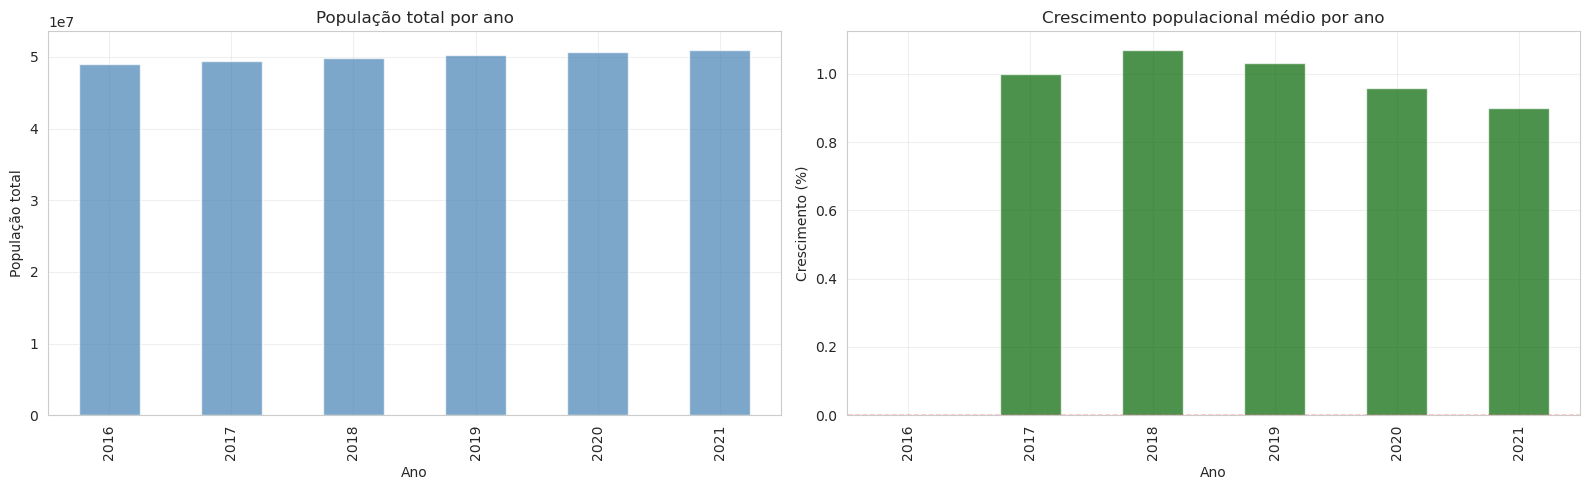

In [14]:
# 13. VISUALIZAÇÕES - POPULAÇÃO
print('\n' + '=' * 80)
print('VISUALIZAÇÕES - POPULAÇÃO')
print('=' * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

pop_por_ano = kpi_populacao.groupby('ano')['populacao_total'].sum()
pop_por_ano.plot(kind='bar', ax=axes[0], color='steelblue', alpha=0.7)
axes[0].set_title('População total por ano')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('População total')
axes[0].grid(alpha=0.3)

cresc_por_ano = kpi_populacao.groupby('ano')['populacao_crescimento_pct'].mean()
cresc_por_ano.plot(kind='bar', ax=axes[1], color='darkgreen', alpha=0.7)
axes[1].set_title('Crescimento populacional médio por ano')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Crescimento (%)')
axes[1].grid(alpha=0.3)
axes[1].axhline(y=0, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig(output_path / 'viz_01_populacao.png', dpi=300, bbox_inches='tight')
print('Gráfico salvo: viz_01_populacao.png')
plt.show()


VISUALIZAÇÕES - IDHM
Gráfico salvo: viz_02_idhm.png


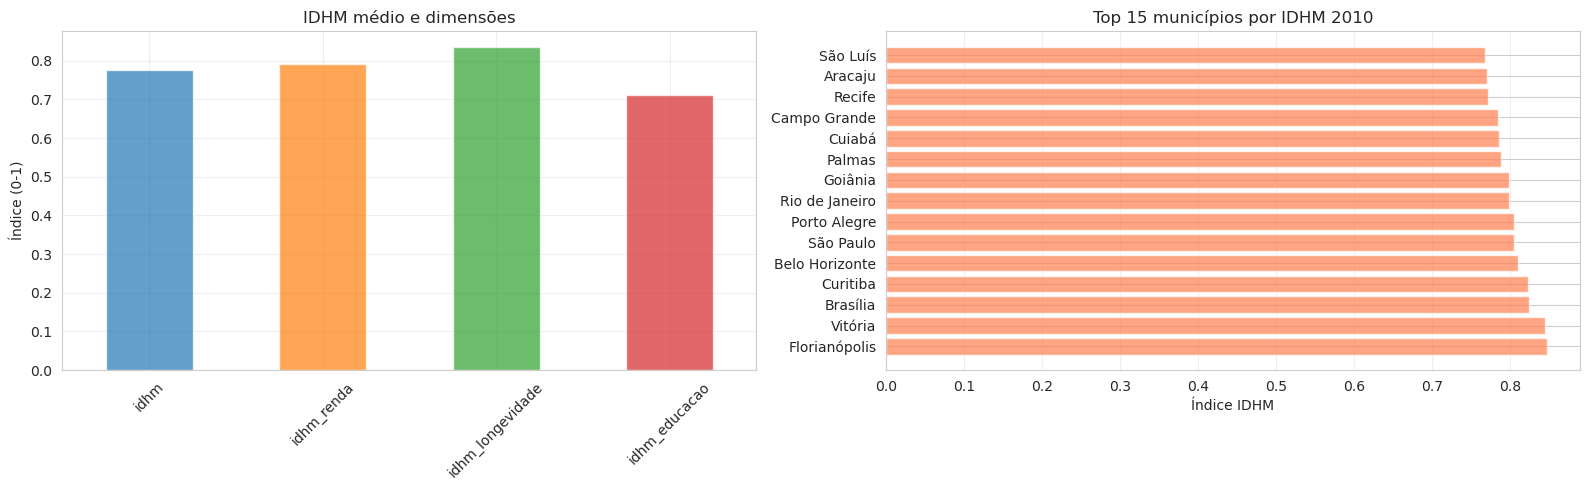

In [15]:
# 14. VISUALIZAÇÕES - IDHM
print('\n' + '=' * 80)
print('VISUALIZAÇÕES - IDHM')
print('=' * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

idhm_medias = kpi_idhm[['idhm', 'idhm_renda', 'idhm_longevidade', 'idhm_educacao']].mean()
idhm_medias.plot(kind='bar', ax=axes[0], color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'], alpha=0.7)
axes[0].set_title('IDHM médio e dimensões')
axes[0].set_ylabel('Índice (0-1)')
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=45)
axes[0].grid(alpha=0.3)

kpi_idhm_unique = kpi_idhm[['municipio', 'idhm']].drop_duplicates().sort_values('idhm', ascending=False)
axes[1].barh(kpi_idhm_unique['municipio'].head(15), kpi_idhm_unique['idhm'].head(15), color='coral', alpha=0.7)
axes[1].set_title('Top 15 municípios por IDHM 2010')
axes[1].set_xlabel('Índice IDHM')
axes[1].grid(alpha=0.3, axis='x')

plt.tight_layout()
plt.savefig(output_path / 'viz_02_idhm.png', dpi=300, bbox_inches='tight')
print('Gráfico salvo: viz_02_idhm.png')
plt.show()


VISUALIZAÇÕES - EDUCAÇÃO
Gráfico salvo: viz_03_educacao.png


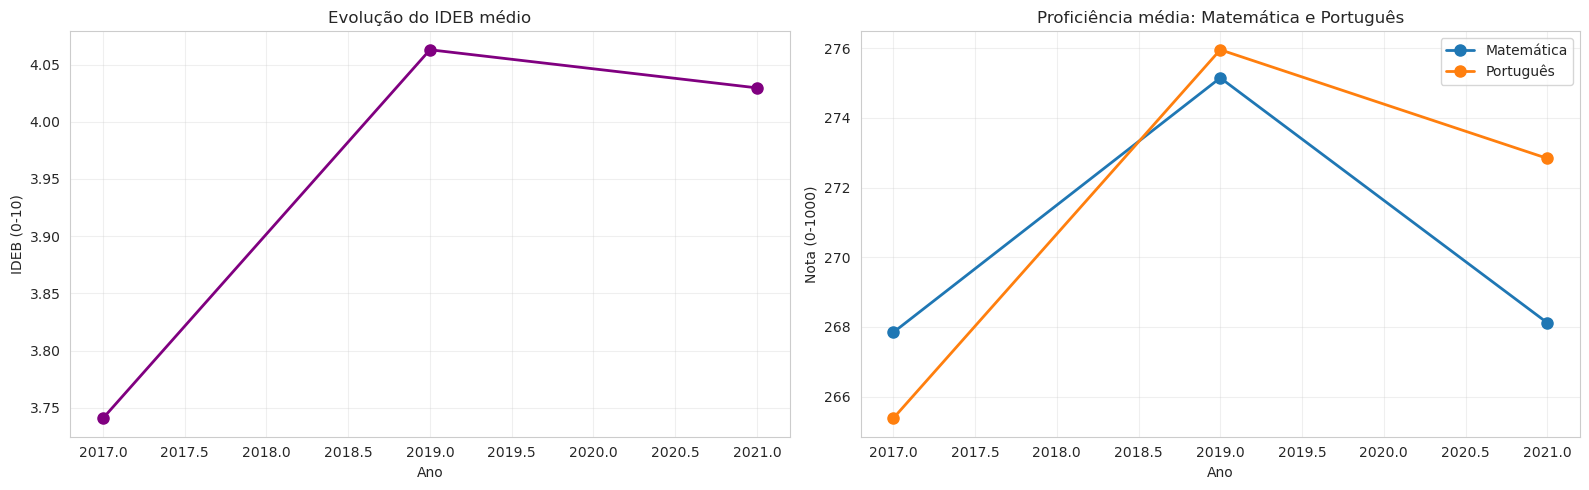

In [16]:
# 15. VISUALIZAÇÕES - EDUCAÇÃO
print('\n' + '=' * 80)
print('VISUALIZAÇÕES - EDUCAÇÃO')
print('=' * 80)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ideb_por_ano = kpi_educacao.groupby('ano')['ideb'].mean()
ideb_por_ano.plot(kind='line', ax=axes[0], marker='o', linewidth=2, color='purple', markersize=8)
axes[0].set_title('Evolução do IDEB médio')
axes[0].set_xlabel('Ano')
axes[0].set_ylabel('IDEB (0-10)')
axes[0].grid(alpha=0.3)

notas_por_ano = kpi_educacao.groupby('ano')[['nota_mt', 'nota_lp']].mean()
notas_por_ano.plot(kind='line', ax=axes[1], marker='o', linewidth=2, markersize=8)
axes[1].set_title('Proficiência média: Matemática e Português')
axes[1].set_xlabel('Ano')
axes[1].set_ylabel('Nota (0-1000)')
axes[1].legend(['Matemática', 'Português'], loc='best')
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'viz_03_educacao.png', dpi=300, bbox_inches='tight')
print('Gráfico salvo: viz_03_educacao.png')
plt.show()


VISUALIZAÇÕES - CRIMES CONTAGENS
Gráfico salvo: viz_04_crimes_contagens.png


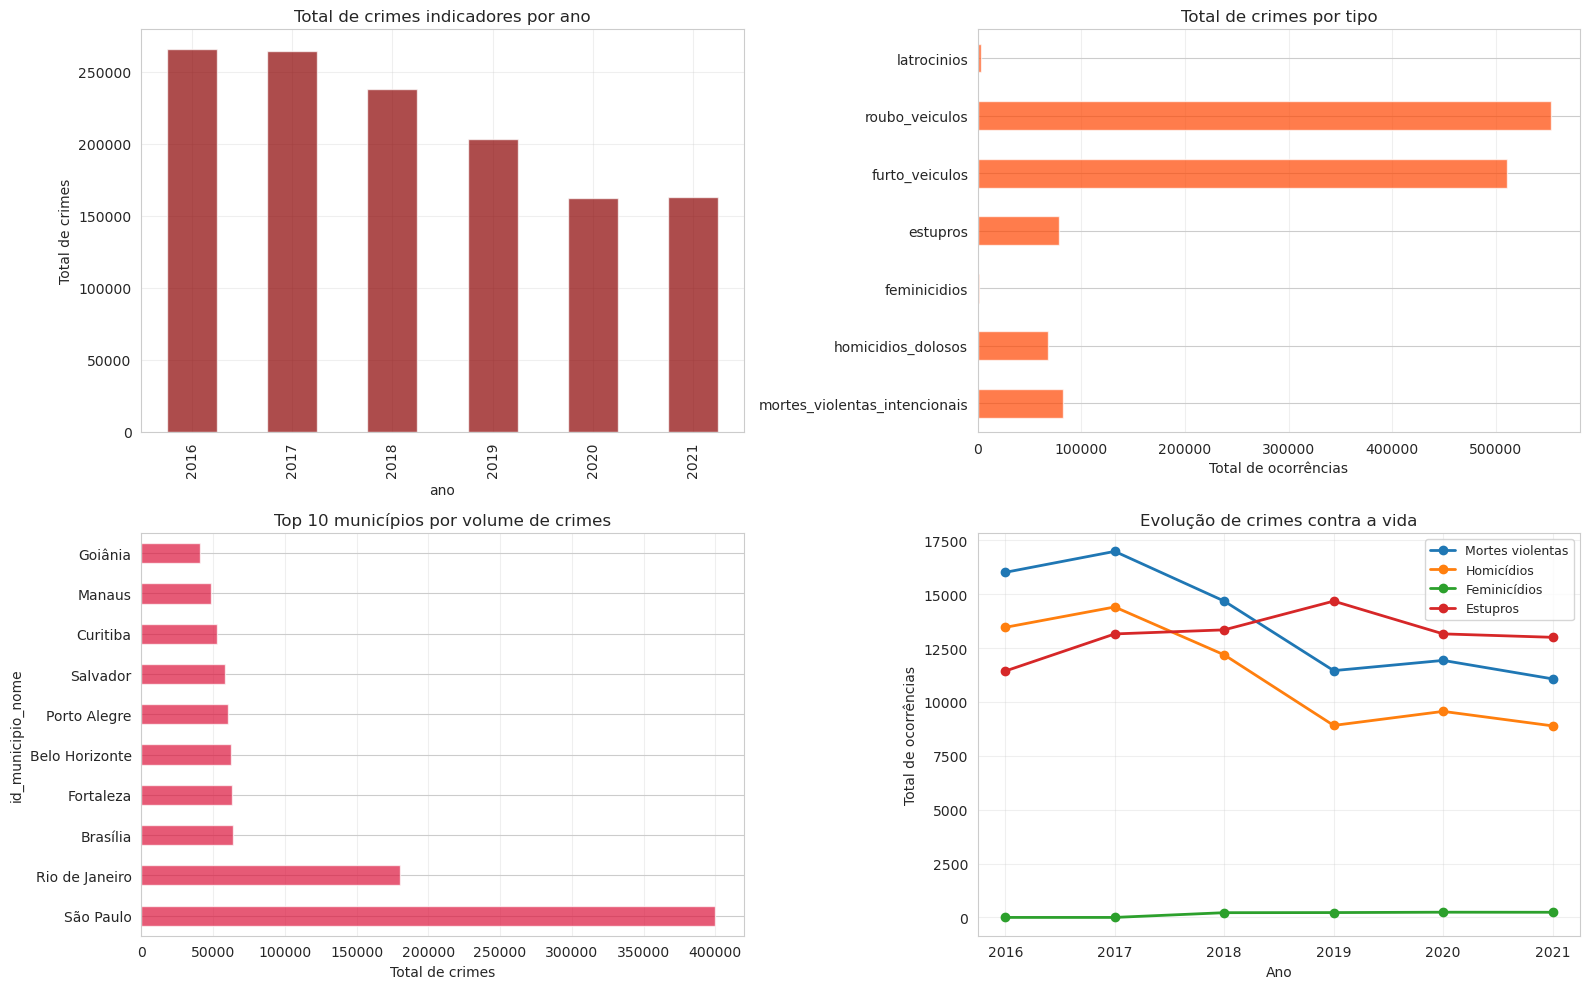

In [17]:
# 16. VISUALIZAÇÕES - CRIMES CONTAGENS
print('\n' + '=' * 80)
print('VISUALIZAÇÕES - CRIMES CONTAGENS')
print('=' * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

crimes_por_ano = kpi_crimes_abs.groupby('ano')['crimes_total_indicadores'].sum()
crimes_por_ano.plot(kind='bar', ax=axes[0, 0], color='darkred', alpha=0.7)
axes[0, 0].set_title('Total de crimes indicadores por ano')
axes[0, 0].set_ylabel('Total de crimes')
axes[0, 0].grid(alpha=0.3)

crime_tipos = kpi_crimes_abs[['mortes_violentas_intencionais', 'homicidios_dolosos', 'feminicidios', 'estupros', 'furto_veiculos', 'roubo_veiculos', 'latrocinios']].sum()
crime_tipos.plot(kind='barh', ax=axes[0, 1], color='orangered', alpha=0.7)
axes[0, 1].set_title('Total de crimes por tipo')
axes[0, 1].set_xlabel('Total de ocorrências')
axes[0, 1].grid(alpha=0.3, axis='x')

crimes_por_municipio = kpi_crimes_abs.groupby('id_municipio_nome')['crimes_total_indicadores'].sum().nlargest(10)
crimes_por_municipio.plot(kind='barh', ax=axes[1, 0], color='crimson', alpha=0.7)
axes[1, 0].set_title('Top 10 municípios por volume de crimes')
axes[1, 0].set_xlabel('Total de crimes')
axes[1, 0].grid(alpha=0.3, axis='x')

crime_evolucao = kpi_crimes_abs.groupby('ano')[['mortes_violentas_intencionais', 'homicidios_dolosos', 'feminicidios', 'estupros']].sum()
crime_evolucao.plot(kind='line', ax=axes[1, 1], marker='o', linewidth=2, markersize=6)
axes[1, 1].set_title('Evolução de crimes contra a vida')
axes[1, 1].set_xlabel('Ano')
axes[1, 1].set_ylabel('Total de ocorrências')
axes[1, 1].legend(['Mortes violentas', 'Homicídios', 'Feminicídios', 'Estupros'], loc='best', fontsize=9)
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'viz_04_crimes_contagens.png', dpi=300, bbox_inches='tight')
print('Gráfico salvo: viz_04_crimes_contagens.png')
plt.show()


VISUALIZAÇÕES - CRIMES TAXAS
Gráfico salvo: viz_05_crimes_taxas.png


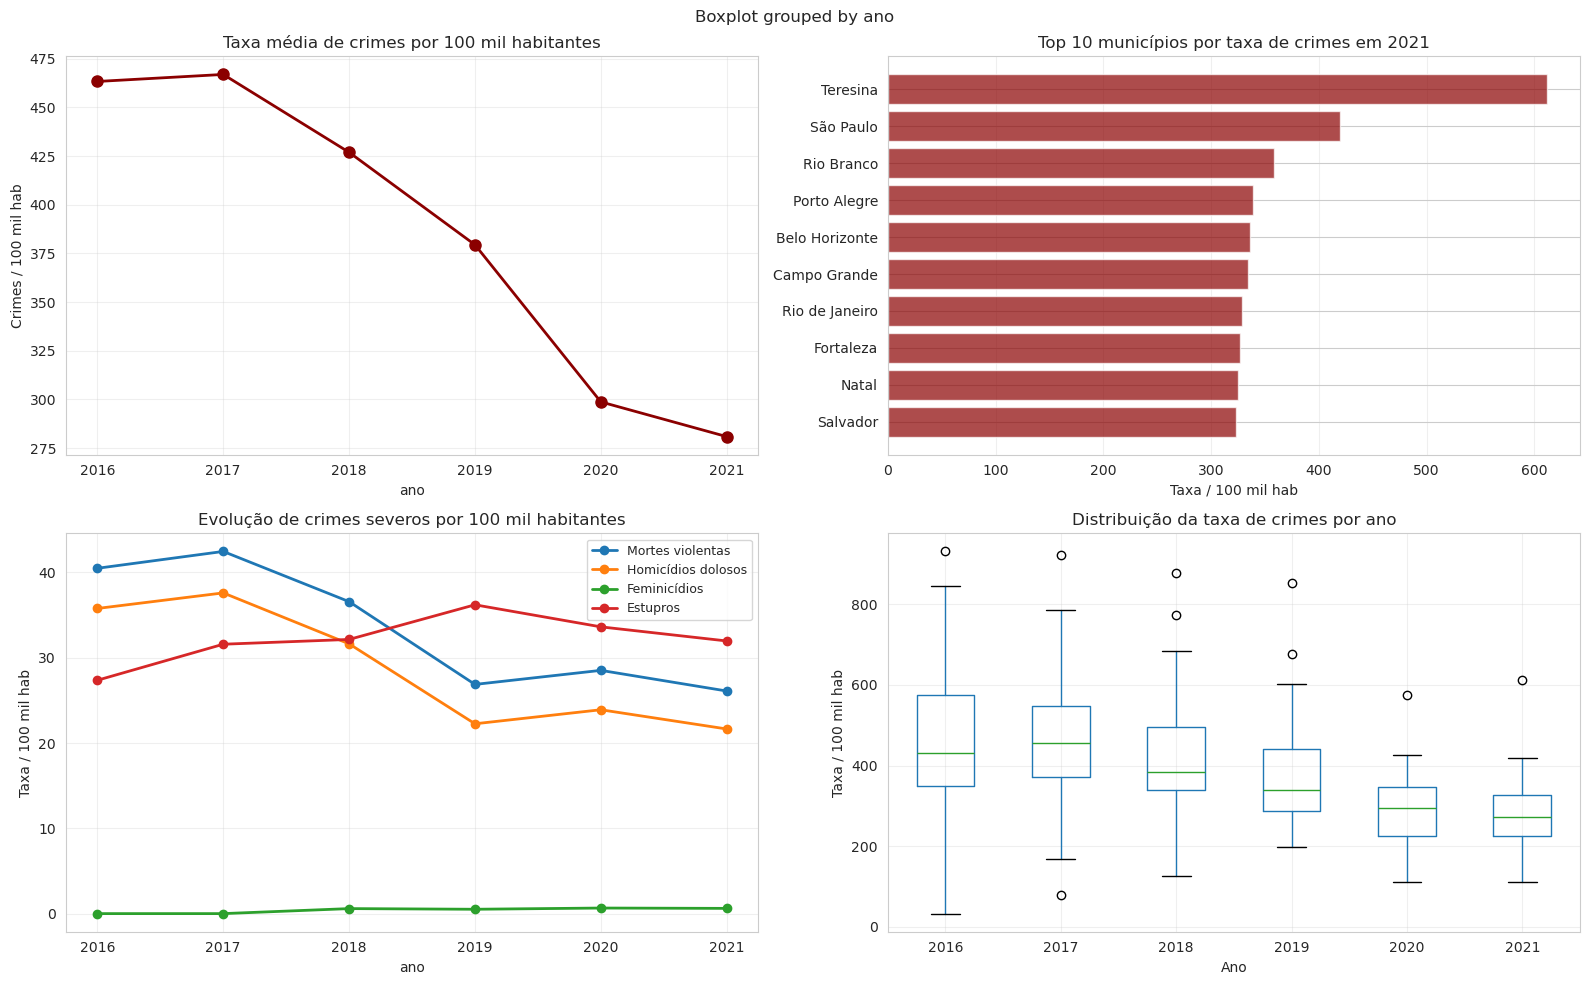

In [18]:
# 17. VISUALIZAÇÕES - CRIMES TAXAS
print('\n' + '=' * 80)
print('VISUALIZAÇÕES - CRIMES TAXAS')
print('=' * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

taxa_crimes_por_ano = kpi_crimes_taxa.groupby('ano')['taxa_crimes_total_indicadores_100k'].mean()
taxa_crimes_por_ano.plot(kind='line', ax=axes[0, 0], marker='o', linewidth=2, color='darkred', markersize=8)
axes[0, 0].set_title('Taxa média de crimes por 100 mil habitantes')
axes[0, 0].set_ylabel('Crimes / 100 mil hab')
axes[0, 0].grid(alpha=0.3)

crimes_2021 = kpi_crimes_taxa[kpi_crimes_taxa['ano'] == 2021].nlargest(10, 'taxa_crimes_total_indicadores_100k')
crimes_2021_sorted = crimes_2021.sort_values('taxa_crimes_total_indicadores_100k')
axes[0, 1].barh(crimes_2021_sorted['id_municipio_nome'], crimes_2021_sorted['taxa_crimes_total_indicadores_100k'], color='darkred', alpha=0.7)
axes[0, 1].set_title('Top 10 municípios por taxa de crimes em 2021')
axes[0, 1].set_xlabel('Taxa / 100 mil hab')
axes[0, 1].grid(alpha=0.3, axis='x')

taxa_severos = kpi_crimes_taxa.groupby('ano')[['taxa_mortes_violentas_intencionais_100k', 'taxa_homicidios_dolosos_100k', 'taxa_feminicidios_100k', 'taxa_estupros_100k']].mean()
taxa_severos.plot(kind='line', ax=axes[1, 0], marker='o', linewidth=2, markersize=6)
axes[1, 0].set_title('Evolução de crimes severos por 100 mil habitantes')
axes[1, 0].set_ylabel('Taxa / 100 mil hab')
axes[1, 0].legend(['Mortes violentas', 'Homicídios dolosos', 'Feminicídios', 'Estupros'], loc='best', fontsize=9)
axes[1, 0].grid(alpha=0.3)

kpi_crimes_taxa_plot = kpi_crimes_taxa.copy()
kpi_crimes_taxa_plot.boxplot(column='taxa_crimes_total_indicadores_100k', by='ano', ax=axes[1, 1])
axes[1, 1].set_title('Distribuição da taxa de crimes por ano')
axes[1, 1].set_xlabel('Ano')
axes[1, 1].set_ylabel('Taxa / 100 mil hab')
axes[1, 1].grid(alpha=0.3)

plt.tight_layout()
plt.savefig(output_path / 'viz_05_crimes_taxas.png', dpi=300, bbox_inches='tight')
print('Gráfico salvo: viz_05_crimes_taxas.png')
plt.show()


VISUALIZAÇÕES - ÍNDICE DE RISCO
Gráfico salvo: viz_06_risco.png


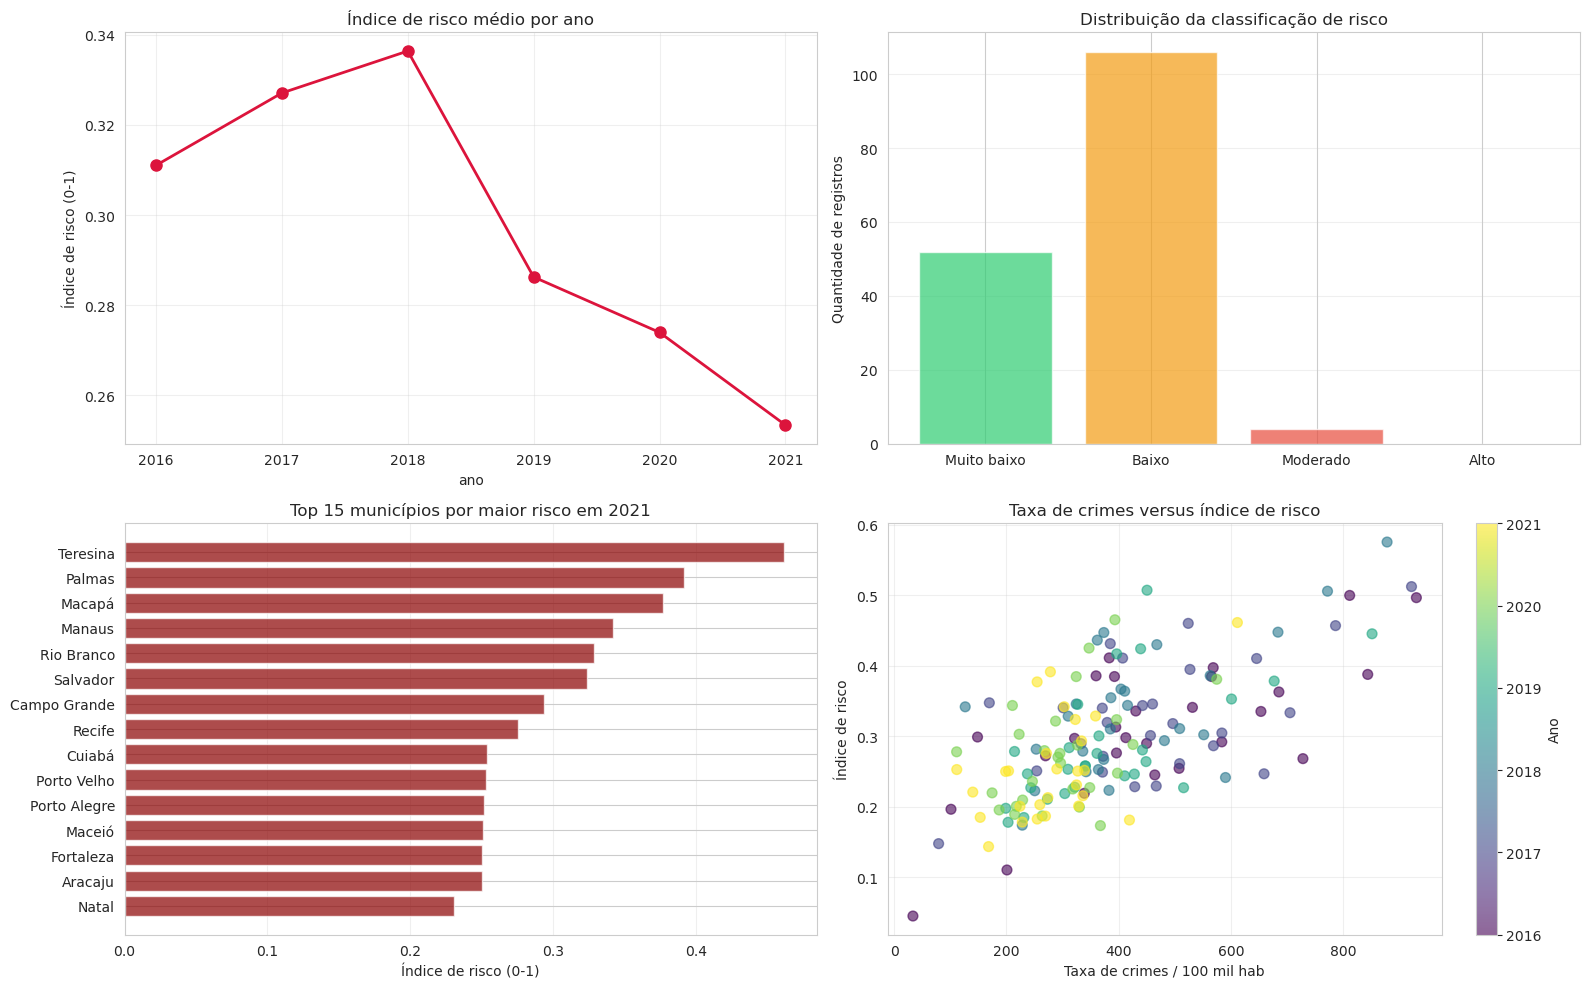

In [19]:
# 18. VISUALIZAÇÕES - ÍNDICE DE RISCO
print('\n' + '=' * 80)
print('VISUALIZAÇÕES - ÍNDICE DE RISCO')
print('=' * 80)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

risco_por_ano = kpi_risco.groupby('ano')['risco_indice'].mean()
risco_por_ano.plot(kind='line', ax=axes[0, 0], marker='o', linewidth=2, color='crimson', markersize=8)
axes[0, 0].set_title('Índice de risco médio por ano')
axes[0, 0].set_ylabel('Índice de risco (0-1)')
axes[0, 0].grid(alpha=0.3)

risco_dist = kpi_risco['classificacao_risco'].value_counts().sort_index()
colors = ['#2ecc71', '#f39c12', '#e74c3c', '#c0392b']
axes[0, 1].bar(risco_dist.index, risco_dist.values, color=colors, alpha=0.7)
axes[0, 1].set_title('Distribuição da classificação de risco')
axes[0, 1].set_ylabel('Quantidade de registros')
axes[0, 1].grid(alpha=0.3, axis='y')

risco_2021 = kpi_risco[kpi_risco['ano'] == 2021].nlargest(15, 'risco_indice').sort_values('risco_indice')
axes[1, 0].barh(risco_2021['id_municipio_nome'], risco_2021['risco_indice'], color='darkred', alpha=0.7)
axes[1, 0].set_title('Top 15 municípios por maior risco em 2021')
axes[1, 0].set_xlabel('Índice de risco (0-1)')
axes[1, 0].grid(alpha=0.3, axis='x')

scatter_data = kpi_risco[['ano', 'id_municipio', 'taxa_crimes_total_indicadores_100k', 'risco_indice']].copy()
scatter = axes[1, 1].scatter(scatter_data['taxa_crimes_total_indicadores_100k'], scatter_data['risco_indice'], c=scatter_data['ano'], cmap='viridis', alpha=0.6, s=50)
axes[1, 1].set_title('Taxa de crimes versus índice de risco')
axes[1, 1].set_xlabel('Taxa de crimes / 100 mil hab')
axes[1, 1].set_ylabel('Índice de risco')
axes[1, 1].grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=axes[1, 1])
cbar.set_label('Ano')

plt.tight_layout()
plt.savefig(output_path / 'viz_06_risco.png', dpi=300, bbox_inches='tight')
print('Gráfico salvo: viz_06_risco.png')
plt.show()

## CORRELAÇÕES EXPLORATÓRIAS - RELAÇÕES ENTRE KPI's


CORRELAÇÕES EXPLORATÓRIAS
Amostra usada para correlação: 729 municípios no ano 2021

Matriz de correlação de Pearson:
                                     idhm  ideb  populacao_total  populacao_crescimento_pct  taxa_crimes_total_indicadores_100k  risco_indice
idhm                                1.000  -0.0            0.235                     -0.159                              -0.039        -0.517
ideb                               -0.000   1.0           -0.000                      0.000                              -0.000        -0.000
populacao_total                     0.235  -0.0            1.000                     -0.313                               0.313        -0.273
populacao_crescimento_pct          -0.159   0.0           -0.313                      1.000                              -0.346         0.062
taxa_crimes_total_indicadores_100k -0.039  -0.0            0.313                     -0.346                               1.000         0.515
risco_indice                 

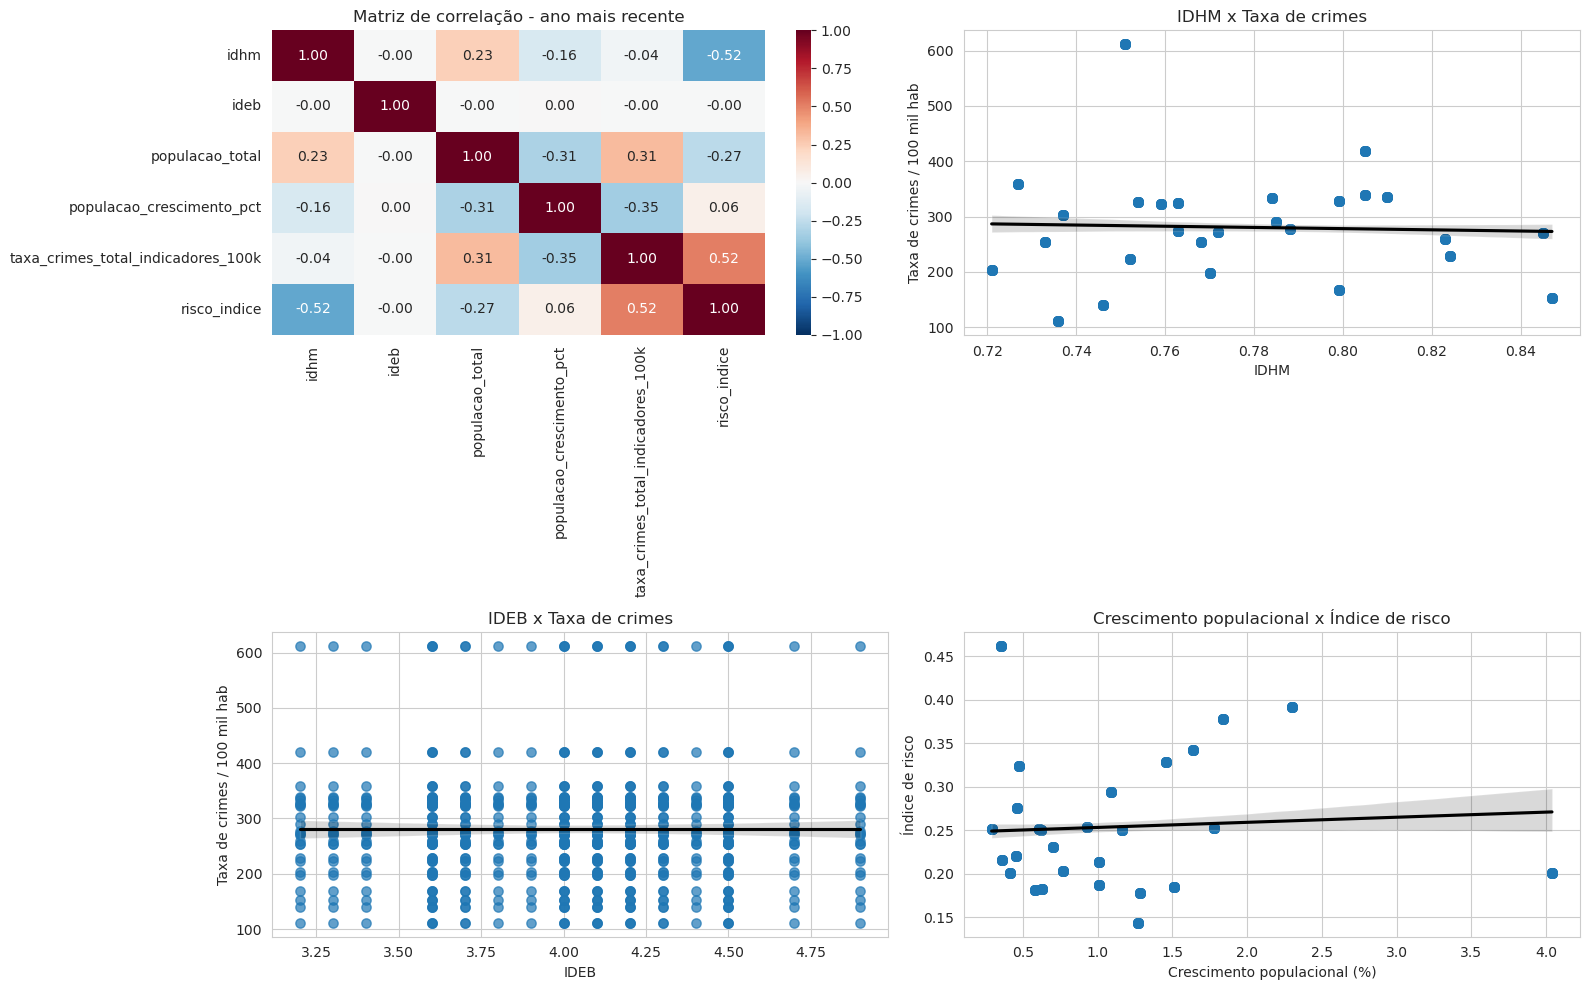

In [20]:
# 21. CORRELAÇÕES EXPLORATÓRIAS ENTRE KPIs
print('\n' + '=' * 80)
print('CORRELAÇÕES EXPLORATÓRIAS')
print('=' * 80)

# Usar o ano mais recente para evitar duplicações de séries repetidas ao longo do tempo
latest_year = df_kpis_consolidado['ano'].max()
df_corr = df_kpis_consolidado[df_kpis_consolidado['ano'] == latest_year].copy()

colunas_corr = [
    'idhm',
    'ideb',
    'populacao_total',
    'populacao_crescimento_pct',
    'taxa_crimes_total_indicadores_100k',
    'risco_indice'
]

df_corr = df_corr[colunas_corr].dropna()
matriz_correlacao = df_corr.corr(method='pearson')

print(f'Amostra usada para correlação: {df_corr.shape[0]} municípios no ano {int(latest_year)}')
print('\nMatriz de correlação de Pearson:')
print(matriz_correlacao.round(3).to_string())

pares = (
    matriz_correlacao.where(np.triu(np.ones(matriz_correlacao.shape), k=1).astype(bool))
    .stack()
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print('\nTop correlações por valor absoluto:')
for (origem, destino), valor in pares.head(5).items():
    print(f'- {origem} x {destino}: {valor:+.3f}')

resumo_relacoes = pd.DataFrame([
    {
        'Relacao': 'IDHM x Taxa de crimes',
        'Pearson': matriz_correlacao.loc['idhm', 'taxa_crimes_total_indicadores_100k'],
        'Leitura': 'Avalia se desenvolvimento humano maior anda junto com menor criminalidade'
    },
    {
        'Relacao': 'IDEB x Taxa de crimes',
        'Pearson': matriz_correlacao.loc['ideb', 'taxa_crimes_total_indicadores_100k'],
        'Leitura': 'Mostra a relação entre qualidade da educação e incidência criminal'
    },
    {
        'Relacao': 'Crescimento populacional x Risco',
        'Pearson': matriz_correlacao.loc['populacao_crescimento_pct', 'risco_indice'],
        'Leitura': 'Verifica se municípios em expansão tendem a acumular mais risco'
    },
    {
        'Relacao': 'População total x Crimes totais',
        'Pearson': matriz_correlacao.loc['populacao_total', 'taxa_crimes_total_indicadores_100k'],
        'Leitura': 'Ajuda a comparar efeito de escala populacional sobre a criminalidade'
    },
])

print('\nResumo técnico das relações principais:')
print(resumo_relacoes.to_string(index=False, justify='left', formatters={'Pearson': '{:+.3f}'.format}))

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

sns.heatmap(
    matriz_correlacao,
    annot=True,
    fmt='.2f',
    cmap='RdBu_r',
    center=0,
    vmin=-1,
    vmax=1,
    ax=axes[0, 0]
)
axes[0, 0].set_title('Matriz de correlação - ano mais recente')

sns.regplot(
    data=df_corr,
    x='idhm',
    y='taxa_crimes_total_indicadores_100k',
    ax=axes[0, 1],
    scatter_kws={'alpha': 0.7, 's': 45},
    line_kws={'color': 'black'}
)
axes[0, 1].set_title('IDHM x Taxa de crimes')
axes[0, 1].set_xlabel('IDHM')
axes[0, 1].set_ylabel('Taxa de crimes / 100 mil hab')

sns.regplot(
    data=df_corr,
    x='ideb',
    y='taxa_crimes_total_indicadores_100k',
    ax=axes[1, 0],
    scatter_kws={'alpha': 0.7, 's': 45},
    line_kws={'color': 'black'}
)
axes[1, 0].set_title('IDEB x Taxa de crimes')
axes[1, 0].set_xlabel('IDEB')
axes[1, 0].set_ylabel('Taxa de crimes / 100 mil hab')

sns.regplot(
    data=df_corr,
    x='populacao_crescimento_pct',
    y='risco_indice',
    ax=axes[1, 1],
    scatter_kws={'alpha': 0.7, 's': 45},
    line_kws={'color': 'black'}
)
axes[1, 1].set_title('Crescimento populacional x Índice de risco')
axes[1, 1].set_xlabel('Crescimento populacional (%)')
axes[1, 1].set_ylabel('Índice de risco')

plt.tight_layout()
plt.savefig(output_path / 'viz_07_correlacoes_kpis.png', dpi=300, bbox_inches='tight')
print('\nGráfico salvo: viz_07_correlacoes_kpis.png')
plt.show()

In [21]:
# 19. RESUMO FINAL E ESTATÍSTICAS GERAIS
print('=' * 80)
print('RESUMO FINAL - 30 KPIs')
print('=' * 80)

summary_data = {
    'Bloco': ['População', 'IDHM', 'Educação', 'Segurança - Contagens', 'Segurança - Taxas', 'Features Temporais', 'Índice de Risco', 'TOTAL'],
    'Qtd KPIs': [2, 4, 5, 8, 7, 3, 1, 30],
}

summary_df = pd.DataFrame(summary_data)
print(summary_df.to_string(index=False))
print(f'Total de indicadores calculados: 30')
print(f'População média por registro: {kpi_populacao["populacao_total"].mean():,.0f}')
print(f'IDHM médio: {kpi_idhm["idhm"].mean():.3f}')
print(f'IDEB médio: {kpi_educacao["ideb"].mean():.2f}')
print(f'Taxa média de crimes: {kpi_crimes_taxa["taxa_crimes_total_indicadores_100k"].mean():.1f} por 100 mil habitantes')
print(f'Risco médio: {kpi_risco["risco_indice"].mean():.3f}')

RESUMO FINAL - 30 KPIs
                Bloco  Qtd KPIs
            População         2
                 IDHM         4
             Educação         5
Segurança - Contagens         8
    Segurança - Taxas         7
   Features Temporais         3
      Índice de Risco         1
                TOTAL        30
Total de indicadores calculados: 30
População média por registro: 1,471,343
IDHM médio: 0.777
IDEB médio: 3.94
Taxa média de crimes: 386.0 por 100 mil habitantes
Risco médio: 0.298


## RESUMO PARA APRESENTAÇÃO (Tabelas e Texto Simples)


In [ ]:
# 20. RESUMO PARA APRESENTAÇÃO: tabela enxuta por KPI (valor mais recente, tendência e top-5)
print("\n" + "=" * 60)
print("RESUMO PARA APRESENTAÇÃO")
print("=" * 60)

latest_year = df_kpis_consolidado['ano'].max()
prev_year = latest_year - 1

# Função auxiliar para formatação
def fmt(x):
    if pd.isna(x):
        return '—'
    if isinstance(x, (int, np.integer)):
        return f"{int(x):,}"
    if isinstance(x, float) and abs(x) >= 1000:
        return f"{x:,.0f}"
    if isinstance(x, float):
        return f"{x:.2f}"
    return str(x)

# KPIs resumidos (coluna no consolidado, label, como agregar: 'sum' ou 'mean')
kpi_summary = [
    ('populacao_total', 'População total', 'sum', 'Total de habitantes (somado sobre municípios)'),
    ('populacao_crescimento_pct', 'Crescimento pop. (%)', 'mean', 'Crescimento anual médio por município (%)'),
    ('idhm', 'IDHM (média)', 'mean', 'Índice de Desenvolvimento Humano (2010) - média das capitais'),
    ('ideb', 'IDEB (média)', 'mean', 'IDEB médio por UF replicado nas capitais'),
    ('crimes_total_indicadores', 'Crimes (total)', 'sum', 'Soma dos indicadores criminais (contagens absolutas)'),
    ('taxa_crimes_total_indicadores_100k', 'Taxa crimes (média/100k)', 'mean', 'Taxa média de crimes por 100k habitantes'),
    ('risco_indice', 'Índice de Risco (média)', 'mean', 'Índice composto 0-1 (média)')
]

rows = []
for col, label, agg, desc in kpi_summary:
    if col not in df_kpis_consolidado.columns:
        val_latest = None
        val_prev = None
    else:
        grp_latest = df_kpis_consolidado[df_kpis_consolidado['ano'] == latest_year]
        grp_prev = df_kpis_consolidado[df_kpis_consolidado['ano'] == prev_year]
        if agg == 'sum':
            val_latest = grp_latest[col].sum()
            val_prev = grp_prev[col].sum() if not grp_prev.empty else np.nan
        else:
            val_latest = grp_latest[col].mean()
            val_prev = grp_prev[col].mean() if not grp_prev.empty else np.nan

    # tendência
    trend = '—'
    if pd.notna(val_latest) and pd.notna(val_prev) and val_prev != 0:
        diff_pct = (val_latest - val_prev) / abs(val_prev) * 100
        trend = f"{diff_pct:+.1f}%"

    # top5 (quando aplicável, usar taxa ou contagem de crimes)
    top5 = ''
    if col in ['crimes_total_indicadores', 'taxa_crimes_total_indicadores_100k', 'risco_indice']:
        df_top = df_kpis_consolidado[df_kpis_consolidado['ano'] == latest_year][['id_municipio_nome', col]].dropna()
        if not df_top.empty:
            df_top = df_top.sort_values(col, ascending=False).head(5)
            top5 = '; '.join([f"{r['id_municipio_nome']} ({fmt(r[col])})" for _, r in df_top.iterrows()])

    rows.append({
        'KPI': label,
        'Valor (último ano)': fmt(val_latest),
        'Variação ano anterior': trend,
        'Top 5 (último ano)': top5,
        'O que significa': desc
    })

summary_present = pd.DataFrame(rows)

# Mostrar de forma legível (tabela simples)
from IPython.display import display, HTML
display(HTML(summary_present.to_html(index=False)))

# Salvar CSV de apresentação
summary_present.to_csv(output_path / 'kpis_resumo_apresentacao.csv', index=False)
print(f"\nResumo para apresentação exportado: {output_path / 'kpis_resumo_apresentacao.csv'}")



RESUMO PARA APRESENTAÇÃO


KPI,Valor (último ano),Variação ano anterior,Top 5 (último ano),O que significa
População total,"1,374,733,026",+2620.4%,,Total de habitantes (somado sobre municípios)
Crescimento pop. (%),1.07,-6.1%,,Crescimento anual médio por município (%)
IDHM (média),0.78,-0.0%,,Índice de Desenvolvimento Humano (2010) - média das capitais
IDEB (média),4.03,—,,IDEB médio por UF replicado nas capitais
Crimes (total),"4,400,001",+2612.5%,"São Paulo (51,976); São Paulo (51,976); São Paulo (51,976); São Paulo (51,976); São Paulo (51,976)",Soma dos indicadores criminais (contagens absolutas)
Taxa crimes (média/100k),280.86,-6.0%,Teresina (611.74); Teresina (611.74); Teresina (611.74); Teresina (611.74); Teresina (611.74),Taxa média de crimes por 100k habitantes
Índice de Risco (média),0.25,-7.5%,Teresina (0.46); Teresina (0.46); Teresina (0.46); Teresina (0.46); Teresina (0.46),Índice composto 0-1 (média)



✅ Resumo para apresentação exportado: ../dados_saida/kpis_resumo_apresentacao.csv
